# K-Means Algorithm (KMA)

This notebook presents an independent **K-Means** clustering workflow using the `KMA` implementation from `bluemath_tk`. It generates a reproducible synthetic dataset, fits the model, examines its centroids, and assigns new observations to their nearest cluster.

> **Objective:** replace a large collection of cases with a smaller set of representative centroids while preserving the main density structure of the data.

## 1. How K-Means works

K-Means partitions $n$ observations into $K$ groups. Every observation is associated with the nearest centroid, and the centroids are updated to minimize the within-cluster sum of squared distances:

$$\underset{\mathcal{C}_1,\ldots,\mathcal{C}_K}{\operatorname{minimize}}\;\sum_{k=1}^{K}\sum_{x_i\in\mathcal{C}_k}\lVert x_i-\mu_k\rVert^2,$$

where $\mu_k$ is the mean of cluster $k$. Unlike MDA, which emphasizes coverage and extremes, K-Means places more centroids in densely populated regions.

In [1]:
import numpy as np
import pandas as pd

from bluemath_tk.datamining.kma import KMA
from utils.plotting import plot_variable_combinations

## 2. Generate a synthetic dataset

The example contains 1,000 sea states described by significant wave height ($H_s$), peak period ($T_p$), and wave direction ($Dir$). The seeded generator makes the example reproducible.

The variables deliberately use different units and ranges. `Dir` is circular: $0^\circ$ and $360^\circ$ describe the same direction and must therefore be handled differently from linear variables.

In [2]:
rng = np.random.default_rng(seed=0)
num_samples = 1000

data = pd.DataFrame(
    {
        "Hs": rng.uniform(0, 7, num_samples),
        "Tp": rng.uniform(3, 20, num_samples),
        "Dir": rng.uniform(0, 360, num_samples),
    }
)
data

,Hs,Tp,Dir
0,4.458732,3.221130,351.821184
1,1.888507,17.071970,21.614853
2,0.286815,11.436136,330.446198
3,0.115693,10.410607,100.623762
4,5.692892,13.230510,28.039356
...,...,...,...
995,5.997608,3.570149,46.200734
996,0.546373,19.474459,280.158051
997,2.683236,12.555625,8.940413
998,1.154046,4.386884,74.755062


## 3. Fit K-Means and assign every observation

### Arguments used

**When creating `KMA`:**

- `num_clusters`: number of groups and centroids to calculate. More clusters describe finer variations but produce a less compact summary.
- `seed`: optional random seed used to initialize the clustering. Setting it makes repeated fits reproducible; it is omitted here to follow the basic comparison example.

**In `fit_predict`:**

- `data`: complete numeric `DataFrame` used to train K-Means and assign clusters.
- `directional_variables`: columns containing angles in degrees. `Dir` is internally represented through circular components so directions close to north remain close to one another. Use `[]` if all columns are linear.

Other useful API arguments include `normalize_data`, which enables normalization; `custom_scale_factor`, which supplies explicit ranges; and `min_number_of_points`, which can enforce a minimum cluster population.

The method returns the cluster assignment information and the nearest centroid associated with every input row. The unique fitted centroids are stored in `kma.centroids`.

In [3]:
num_clusters = 50
directional_variables = ["Dir"]

kma = KMA(num_clusters=num_clusters)
cluster_assignments, nearest_centroids = kma.fit_predict(
    data=data,
    directional_variables=directional_variables,
)
kma.centroids

,Hs,Tp,Dir_u,Dir_v,Dir
0,4.287571,5.427486,0.298311,-0.747536,158.245115
1,2.719726,16.461863,-0.359558,-0.156599,246.465294
2,3.623228,9.005176,-0.640606,0.436148,304.248471
3,5.727129,19.056687,0.616515,-0.227069,110.219287
4,1.330571,12.794513,0.444559,-0.497165,138.197305
5,6.185514,11.504430,0.205608,0.456670,24.238820
6,3.100683,3.790041,0.359723,-0.565392,147.534006
7,4.375154,15.108353,0.143874,-0.313757,155.366059
8,0.716878,7.323710,-0.039106,0.425246,354.745836
9,5.975278,9.145577,-0.661146,-0.464146,234.929888


## 4. Inspect the centroids

Each centroid represents the mean conditions of one cluster. The checks below compare the original and reduced dataset sizes. Pairwise plots overlay the centroids on the complete cloud; denser areas should generally contain more centroids because K-Means minimizes average within-cluster distance.

In [4]:
print(f"Original observations: {len(data):,}")
print(f"Requested clusters: {num_clusters:,}")
print(f"Calculated centroids: {len(kma.centroids):,}")
nearest_centroids.head()

Original observations: 1,000
Requested clusters: 50
Calculated centroids: 50


,Hs,Tp,Dir_u,Dir_v,Dir
28,4.616869,3.854843,0.133979,0.688185,11.016821
26,1.224970,16.587849,0.249645,0.760491,18.173379
43,0.490435,12.718799,0.104774,0.777697,7.672901
37,0.674099,10.058629,0.208513,-0.666147,162.619208
44,5.460194,13.175239,0.579692,0.714515,39.052745


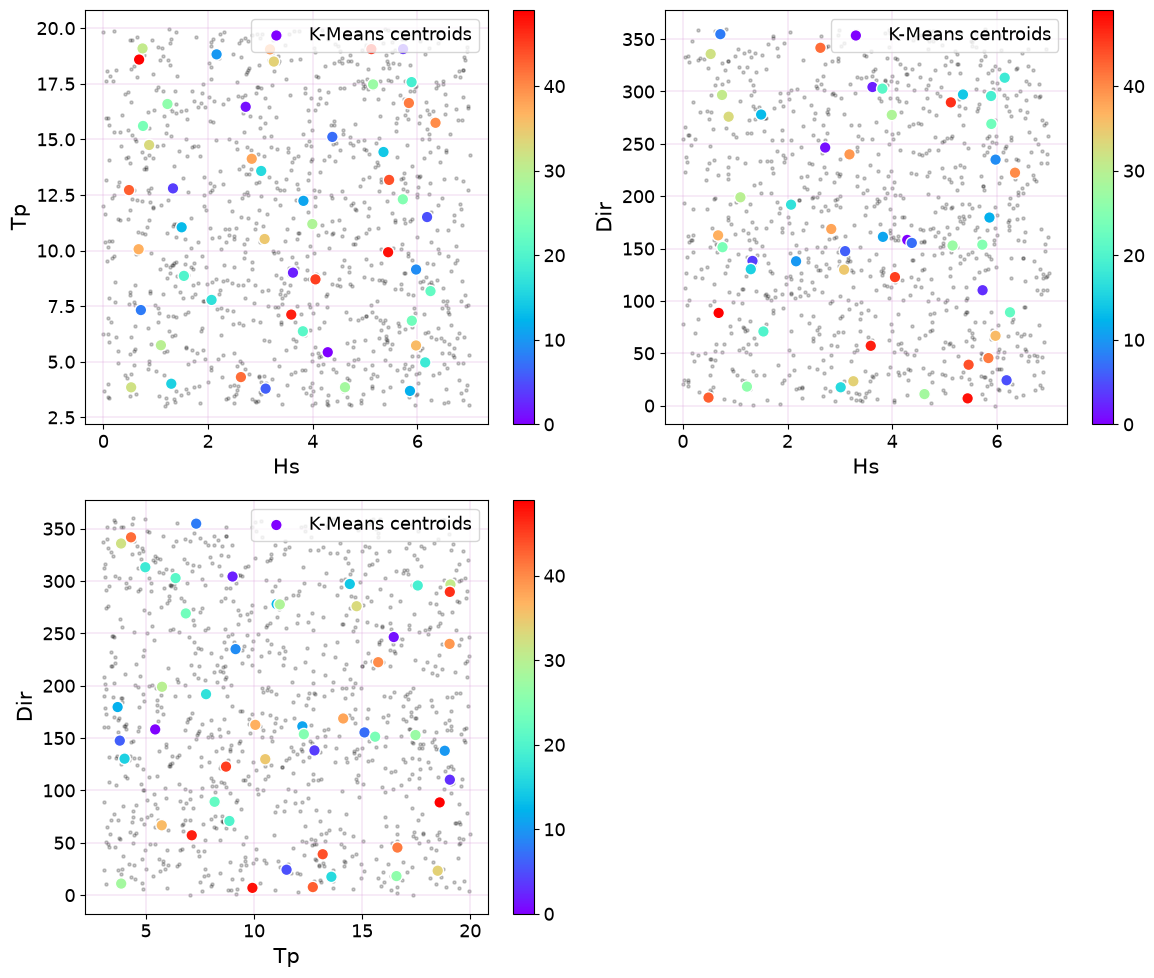

In [5]:
variables = ["Hs", "Tp", "Dir"]
plot_variable_combinations(
    kma.data,
    variables,
    kma.centroids,
    labels="K-Means centroids",
)

## 5. Assign new observations

Once fitted, `predict(data)` assigns new cases without recalculating the centroids.

- `data`: new `DataFrame` containing the same input columns used during fitting. Column names and units must remain consistent.

The first returned object contains the cluster membership (`kma_bmus`), while the second contains the nearest centroid values. The example displays each new case beside its representative centroid.

In [6]:
new_data = pd.DataFrame(
    {
        "Hs": [4, 2, 6],
        "Tp": [12, 10, 15],
        "Dir": [90, 350, 280],
    }
)
new_data

,Hs,Tp,Dir
0,4,12,90
1,2,10,350
2,6,15,280


In [7]:
predicted_clusters, predicted_centroids = kma.predict(new_data)

prediction_summary = new_data.copy()
prediction_summary["Cluster"] = predicted_clusters.kma_bmus.to_numpy()
prediction_summary.join(
    predicted_centroids.add_prefix("Centroid_")
)

,Hs,Tp,Dir,Cluster,Centroid_Hs,Centroid_Tp,Centroid_Dir_u,Centroid_Dir_v,Centroid_Dir
0,4,12,90,11,NaN,NaN,NaN,NaN,NaN
1,2,10,350,13,NaN,NaN,NaN,NaN,NaN
2,6,15,280,14,NaN,NaN,NaN,NaN,NaN


## Interpretation and practical considerations

- Cluster labels are identifiers only; cluster 0 is not intrinsically smaller or more important than cluster 1.
- K-Means is sensitive to variable scaling because it is distance-based. Consider normalization when columns have strongly different ranges or scientific weights.
- The number of clusters controls the balance between compression and detail. It should be selected using the intended application and, when appropriate, diagnostics such as inertia or validation stability.
- Centroids are averages and do not necessarily coincide with actual observations.

## Summary

K-Means reduced 1,000 synthetic sea states to 50 representative centroids and assigned both training and new observations to their closest cluster. Direction was handled as a circular variable, avoiding the discontinuity between $0^\circ$ and $360^\circ$.